# Importar Dataset de Titanic

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = sns.load_dataset("titanic")
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
df.shape

(891, 15)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 100.4 KB


In [5]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


# Exploracion de la data

In [6]:
#contando la cantida de nulos
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

<Axes: >

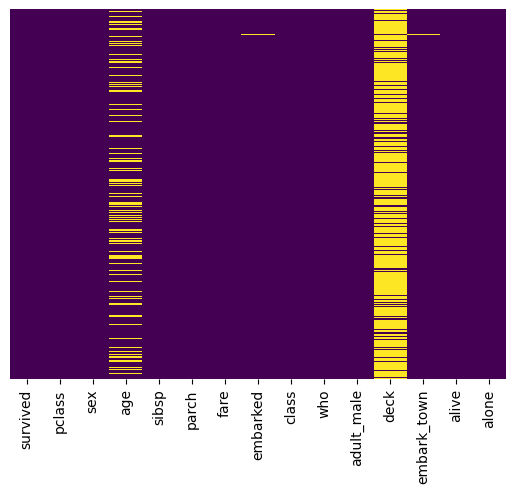

In [7]:
#visualizando los valores nulos
sns.heatmap(df.isnull(), yticklabels= False,cbar=False, cmap='viridis')

In [8]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='str')

#### Explicacion de cada columna:
- Survived: Supervivencia de cada pasajero. 1 = sobrevive . 0 = no sobrevive.
- PClass: Clase del pasajero, sirviendo como indicativo socio-economico (1 = Upper, 2 = Middle, 3 = Lower/Working class).
- Sex: Género del pasajero (Male/Female).
- Age: Edad en años. Esta como float debido a los bebes.
- Sibsp: Numero de hermano o esposos/as que tenia el pasajero.
- Parch: Numero de padres o hijos que tenia el pasajero.
- Fare: Valor del ticket en Libras Britanicas.
- Embarked: Lugar donde el pasajero embarco. C = Cherbourg, Q = Queenstown, S = Southampton.
- Class: Version categorica de Pclass
- Who: Categorizado en man, woman, o child.
- Adult_male: Booleano que evalua si el pasajero era un varon adulto.
- Deck: El nivel de la cubierta donde se encontraba la cabina del pasajero.
- Embark_town: Nombre completo de la ciudad de embarco (Cherbourg, Queenstown, Southampton).
- Alive: Valor categorico de 'survived'.
- Alone: Valor booleano que indica si el pasajero viajaba solo.

# Limpiando data

In [9]:
#como la mayoria de la data en deck es nula, bien se podria sacar la columna.
# En cambio esto no es una opcion para la variable 'ages' ya que es una de las variables mas cruciales en el dataset,
# entonces a los datos nulos que contenga se cambiaran por el promedio de edades basados en su genero

df.drop(columns = 'deck', inplace=True)
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'embark_town', 'alive',
       'alone'],
      dtype='str')

In [10]:
mean_ages = df.groupby('sex')['age'].mean() #promedio de edades por genero
mean_ages

sex
female    27.915709
male      30.726645
Name: age, dtype: float64

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       2
class          0
who            0
adult_male     0
embark_town    2
alive          0
alone          0
dtype: int64

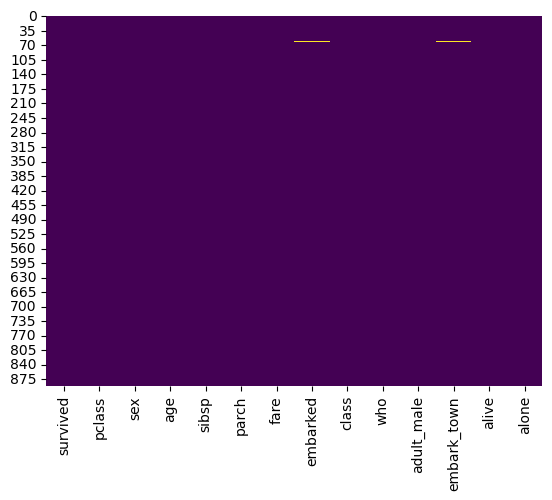

In [11]:
#rellenando los valores nulos de la columna 'age' con el promedio de edades
df['age'] = df.apply(
    lambda row: mean_ages[row['sex']] 
    if pd.isnull(row['age']) 
    else row['age'],
    axis=1
)
#Heat_map
sns.heatmap(df.isnull(),cmap = 'viridis', cbar = False)
df.isnull().sum()

# Explorando distribuciones

<Axes: >

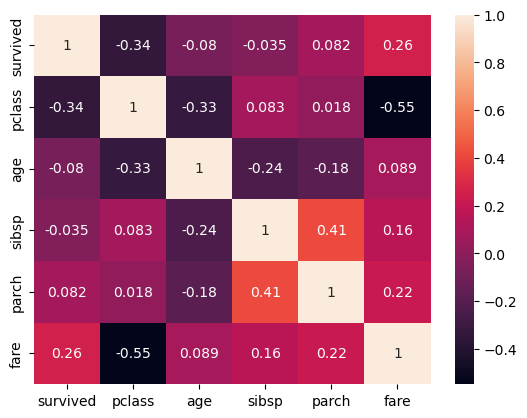

In [12]:
# para explorar la correlacion de los datos, se utiliza una matriz de confusion
# como la matriz de confusion solo acepta numeros, entonces seleccionamos los valores numericos del dataset

df_numeric = df.select_dtypes(include=['float64','int64'])
sns.heatmap(df_numeric.corr(), annot=True) #annot : anotaciones

<Axes: xlabel='age', ylabel='Count'>

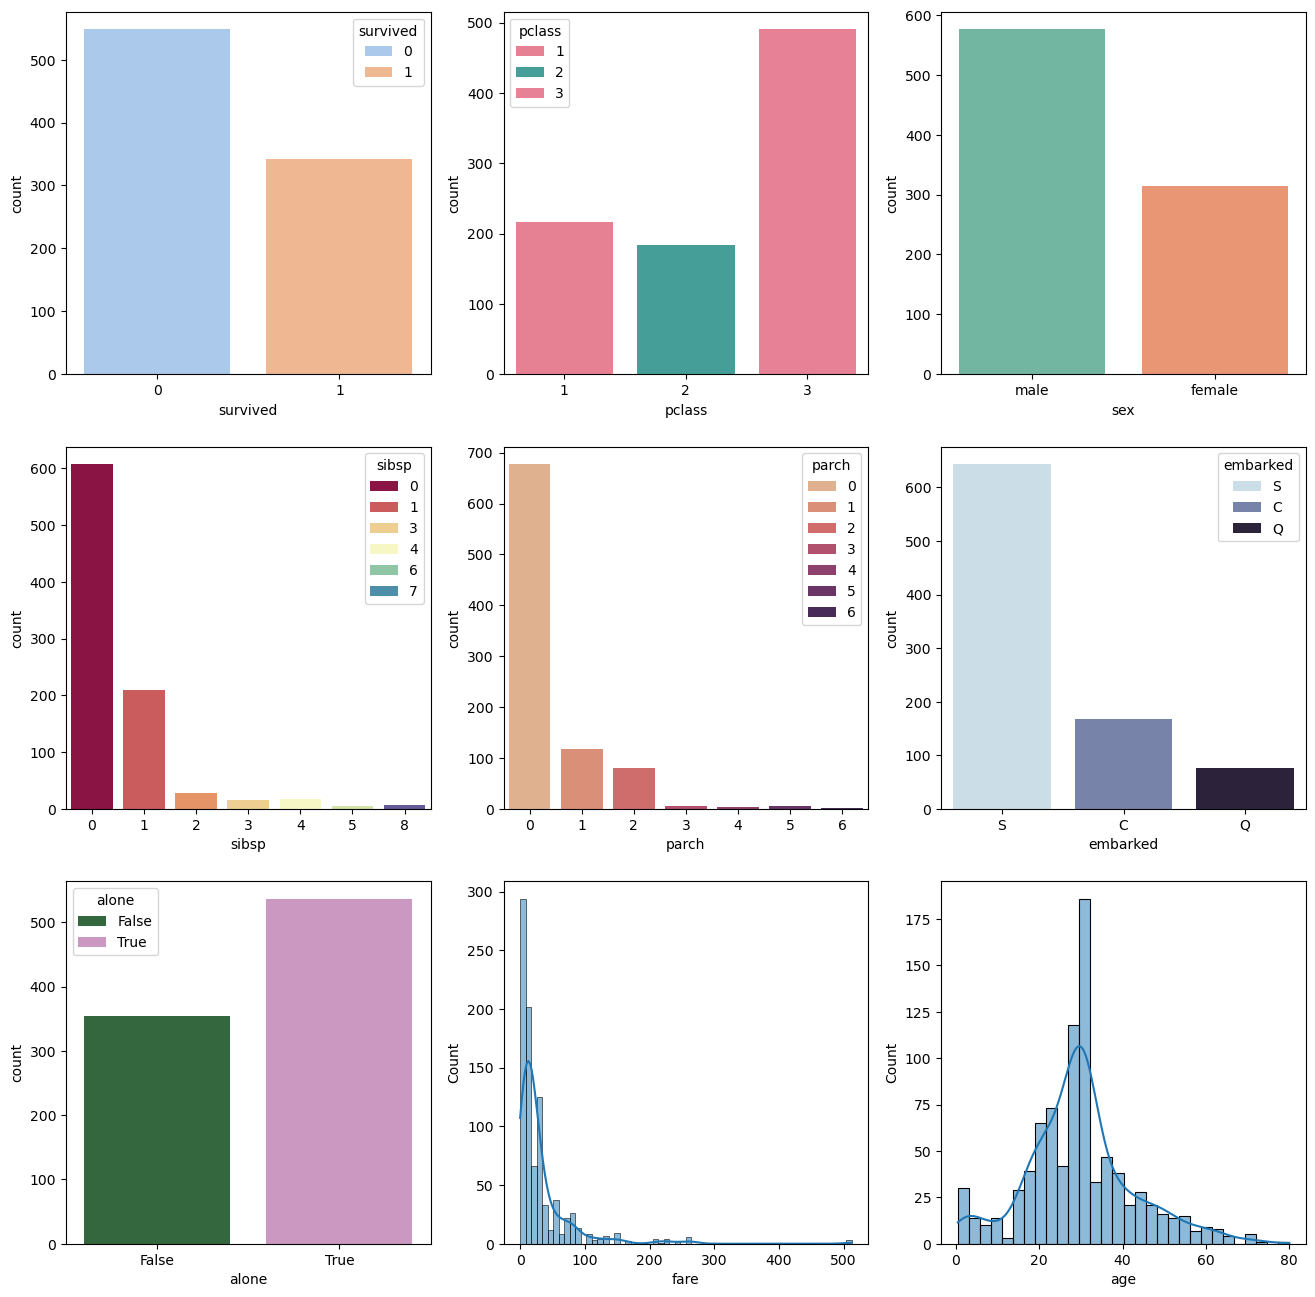

In [13]:
# Visualizando univariablemente

#Crea un conjunto de graficos de 2x3 con un tamaño total de 16x16
fig, ax = plt.subplots(3,3, figsize=(16,16))

#Conteo de pasajeros que sobrevivieron. Se observa que la mayoria no pudo sobrevivir
sns.countplot(x = 'survived', data=df, ax=ax[0][0], hue = 'survived', palette = 'pastel')

#Conteo de los pasajeros por clase. Una gran mayoria era de la clase trabajadora, mientras que la menos pertenecia a la clase2.
sns.countplot(x = 'pclass', data=df, ax=ax[0][1], hue = 'pclass', palette= 'husl')

#Conteo de los pasajeros por tipo de genero. Se visualiza una gran cantidad de hombres comparadas a mujeres
sns.countplot(x = 'sex', data=df, ax=ax[0][2], hue = 'sex', palette='Set2' )

#Conteo de hermanos/as o esposos/as que tenia el pasajero. Se visualiza q
sns.countplot(x = 'sibsp', data=df, ax=ax[1][0], hue = 'sibsp',  palette='Spectral')

#Conteo de pasajeros que tenian padres o hijos. Se observa que casi 700 pasajeros no tenian padre/hijos, poco mas de 100 tenian
# 1 y casi 100 pasajeros tenian 2 padres/hijos.
sns.countplot(x = 'parch', data=df, ax=ax[1][1], hue = 'parch', palette='flare')

#Conteo de pasajeros que embarcaron en un determinado puerto (Cherbourg, Queenstown, Southampton). La mayoria de pasajeros
# embarcó en el puerto de Southampton con una cantidad superior a 600, y el puerto donde menos gente embarco fue el de Queenstown
sns.countplot(x = 'embarked', data=df, ax=ax[1][2], hue = 'embarked', palette='ch:s=.25,rot=-.25')

#Conteo de pasajeros que viajaban solos, se observa que mas de 500 personas viajaban sin acompañantes.
sns.countplot(x = 'alone',data=df,ax=ax[2][0], hue='alone', palette='cubehelix')

#Segun la curva que muestra el grafico, la mayoria de los pasajeros tuvieron una tarifca menor a 50 (tipo de moneda)
sns.histplot(df['fare'], kde=True, ax=ax[2][1])

#Se infiere que la mayoria de gente tenia alrededor de 30 años, mientras que los que se pueden considerar adulto mayor
# eran muy pocos.
sns.histplot(df['age'], kde=True, ax=ax[2][2])

# Analisis multivariado

Se quiere saber quienes sobrevivieron al accidente del Titanic, asi que primero veremos el porcentaje de superviviencia con 
respecto a la clase de pasajeros.

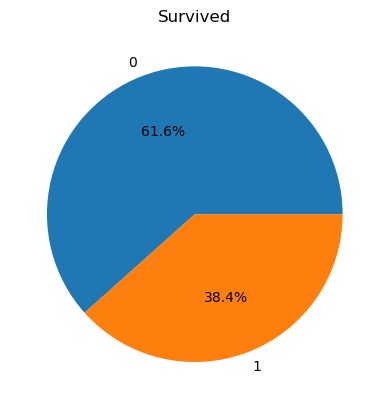

In [14]:
#Se muestra un porcentaje de supervivencia de un 38.4%

df['survived'].value_counts().plot.pie(autopct='%1.1f%%').set_title('Survived')
plt.show()

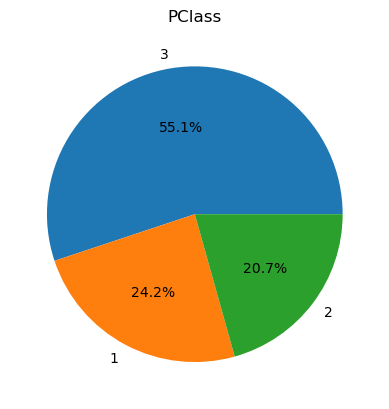

In [15]:
df['pclass'].value_counts().plot.pie(autopct='%1.1f%%').set_title('PClass')
plt.show()

In [16]:
#Se agrupa la data por clase de pasajero para analizar la distribucion de los supervivientes.
df.groupby('pclass')['survived'].value_counts()

pclass  survived
1       1           136
        0            80
2       0            97
        1            87
3       0           372
        1           119
Name: count, dtype: int64

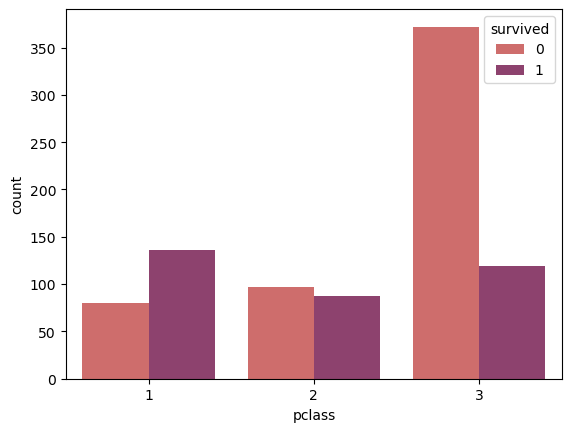

In [17]:
#Gráficamos el ratio de supervivientes por clase de forma grupal. Se visualiza claramente que la clase de pasajeros
#influye en la superviviencia, ya que la mayor cantidad de gente que fallecio pertenecia a la clase 3.

sns.countplot(x = 'pclass',hue='survived',data=df, palette='flare')
plt.show()

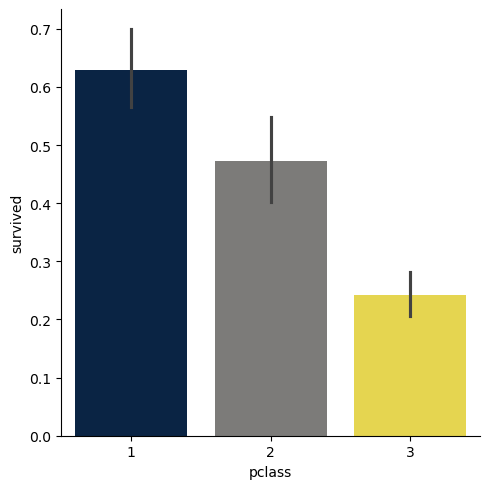

In [18]:
#PLoteando un grafico de barras para comparar la tasa de supervivencia que tuvo cada pasajero por clase
# La supervivencia esta directamente relacionada con la clase del pasajero.
sns.catplot(x = 'pclass', y= 'survived', kind = 'bar', data = df, palette='cividis', hue = 'pclass', legend = False) #hue y legend son solo para que no aparezca un error al correr la celda. Nuevas versiones cambiaran el formato.

<Axes: xlabel='sex', ylabel='count'>

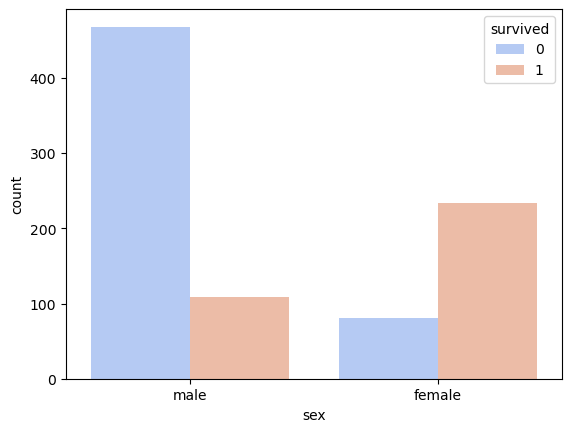

In [19]:
#Grafico de supervivencia segun el genero. 
# Se aprecia que las mujeres pudieron mas que los hombres debido al contexto historico en el que se elegia salvar primero a 
# mujeres y niños.
sns.countplot(x= 'sex',hue='survived',data=df, palette="coolwarm")

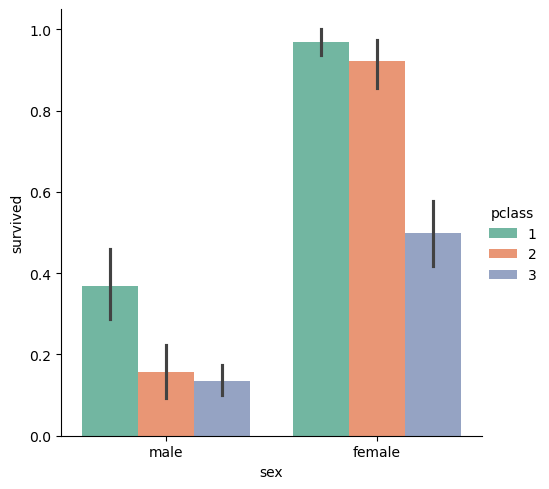

In [20]:
#Grafico de supervivencia segun el genero analizando segun la clase del pasajero.
# La influencia del genero es significativamente mayor a la de la clase de pasajero.
sns.catplot(x = 'sex', y='survived', hue='pclass',kind='bar', data = df, palette='Set2')

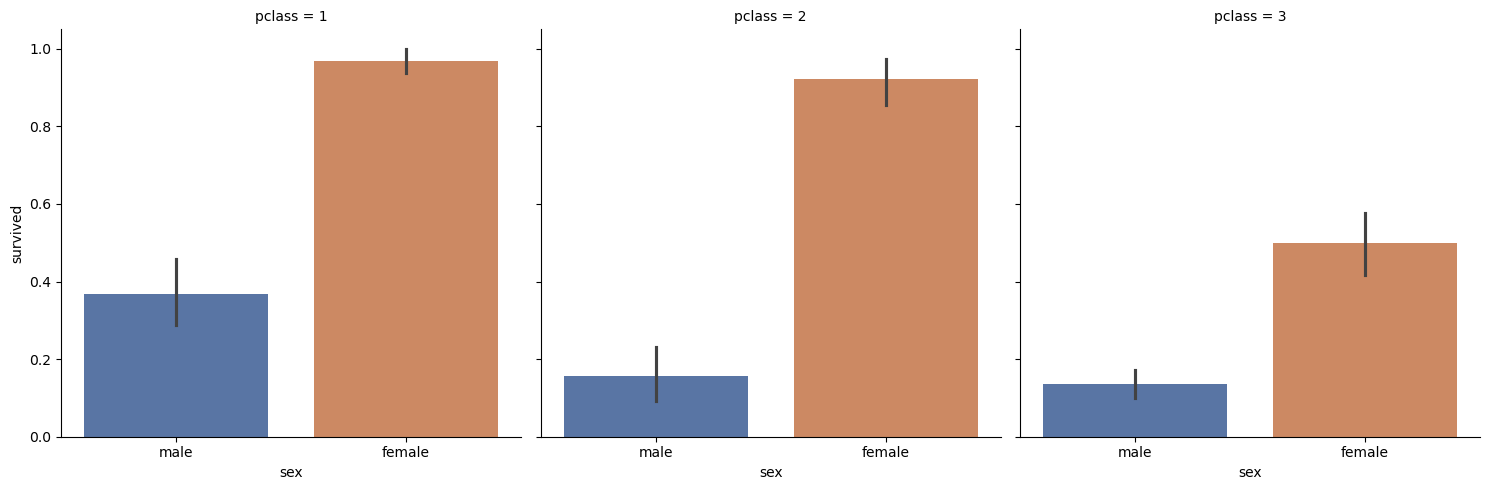

In [21]:
#Mismo grafico que el anterior pero este compara el genero segun clase, uno al lado del otro.
# Se confirma que en cada caso, el genero tuvo una influencia significativa a la hora de sobrevivir.

sns.catplot(x = 'sex', y='survived', col='pclass',kind='bar', data = df, palette='deep', hue = 'sex', legend= False)

## Supervivencia por edad

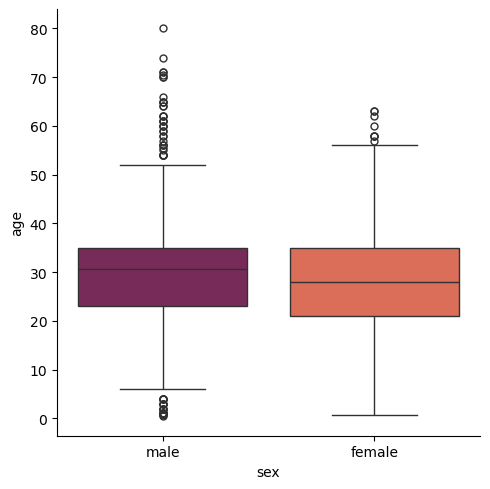

In [22]:
#Grafico de caja para ver donde se concentran los datos
# El promedio de mujeres es menor al de hombres. La edad de los hombres rondaba en los 30 en su mayoria.
# El rango entre Q3-Q1 es mayor en el caso de las mujeres.

sns.catplot(x= 'sex', y= 'age', data=df, kind= 'box', palette= 'rocket', hue='sex', legend = False)

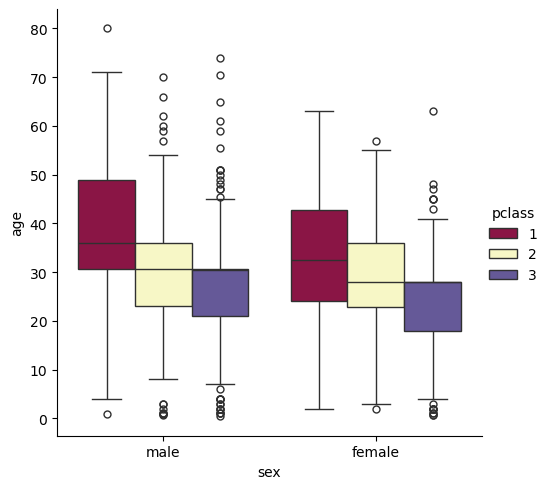

In [23]:
#Grafico de caja para la edad de los pasajeros segun su género, analizando la clase de estos.
# Se visualiza que en su mayoria, la edad promedio de los hombres era mas alta que las mujeres, y mientras mas alta
# la clase de los pasajeros, mas posibilidades de sobrevivir.
# Tambien destacar que mientras mas alta la clase, mas edad tenia el promedio de gente.
sns.catplot(x= 'sex', y= 'age', hue = 'pclass', data=df, kind= 'box', palette= 'Spectral', legend = 'auto')

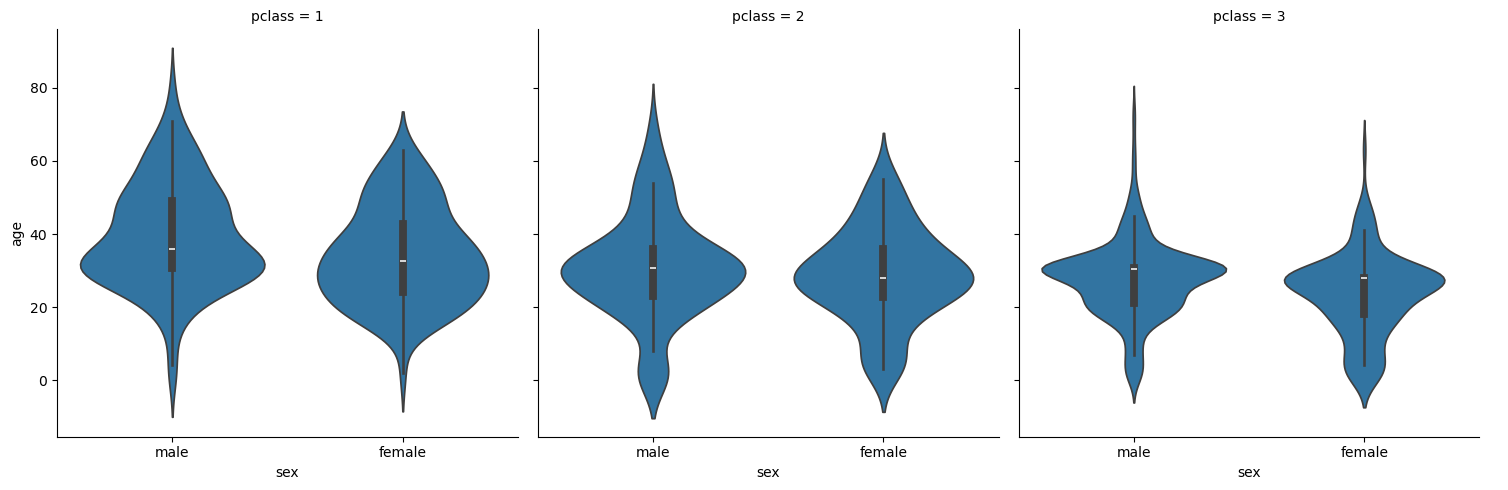

In [24]:
#Grafica de violin para indicar la distribucion de la edad por genero con analisis de data de la clase
# La distribucion de las edades disminuye con la clase. Por lo que se puede inferir que en la clase 3 era el grupo mas joven
sns.catplot(x = 'sex', y = 'age', data=df, col='pclass', kind = 'violin')

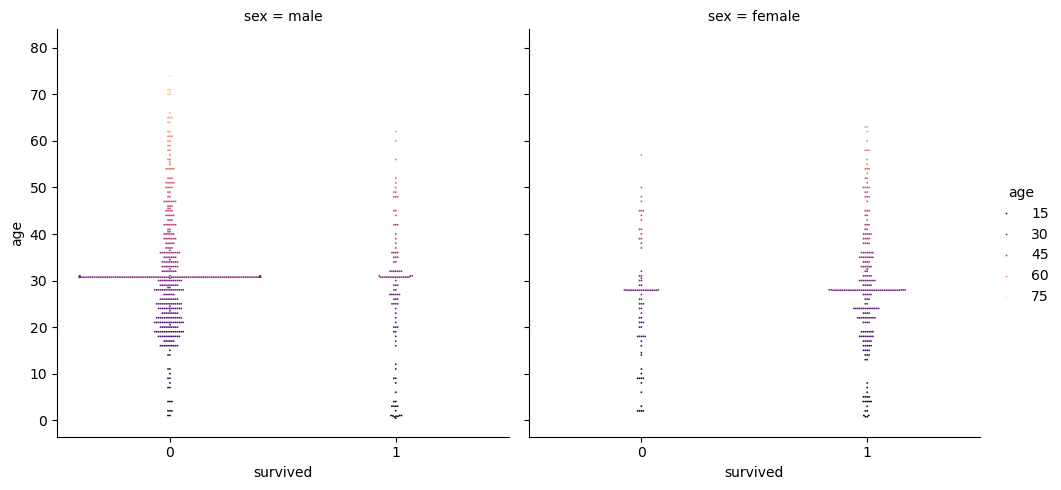

In [25]:
#Grafico de abejas/enjambre para identificar la distribucion de supervivencia segun la edad por clase.
# Los hombres menores a 30 tuvieron la mayor tasa de mortalidad.
sns.catplot(x='survived', y='age', col = 'sex', data = df, kind = 'swarm', palette='magma', hue = 'age', size = 1.3) #se tuvo que especificar el tamaño de las muestras, ya que con el valor por defecto se perdia data en el grafico

## Supervivencia por tarifa

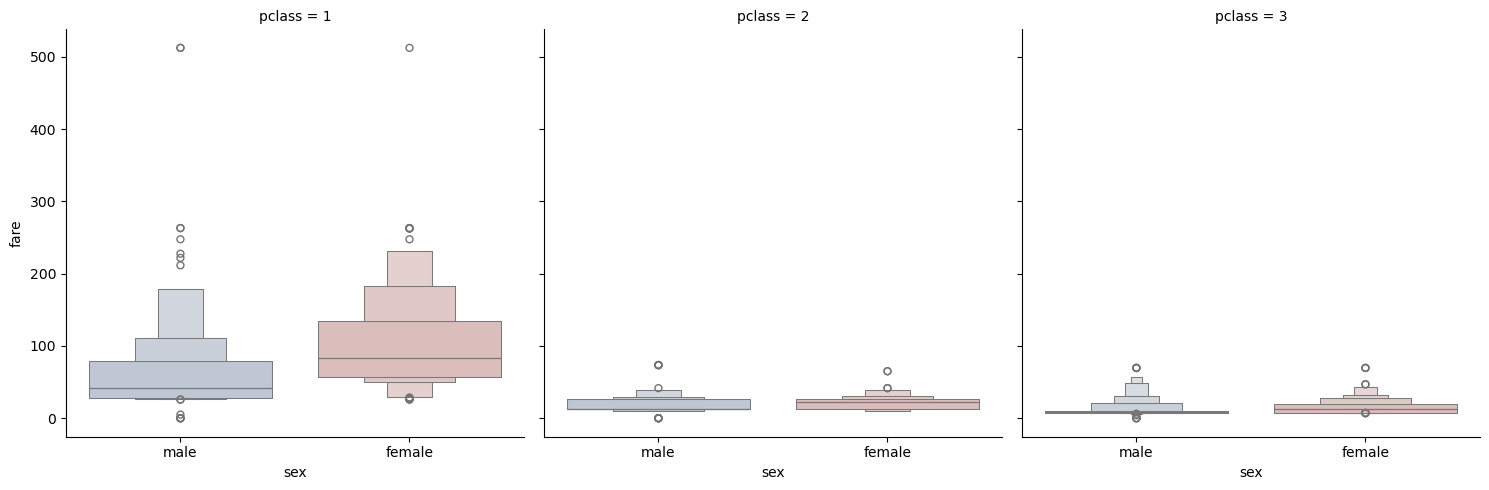

In [26]:
#Grafico de tarifa segun su genero, dividido segun sus clases.
# La primera clase pago tarifas significativamente mas altas comparadas a los demas
sns.catplot(x='sex', y = 'fare', col='pclass', kind='boxen', data = df, palette = 'vlag' , hue ='sex', legend=False)

C:\ProgramData\anaconda3\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 11.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\ProgramData\anaconda3\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 59.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\ProgramData\anaconda3\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 27.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


C:\ProgramData\anaconda3\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 32.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\ProgramData\anaconda3\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 24.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\ProgramData\anaconda3\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 72.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\ProgramData\anaconda3\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 48.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


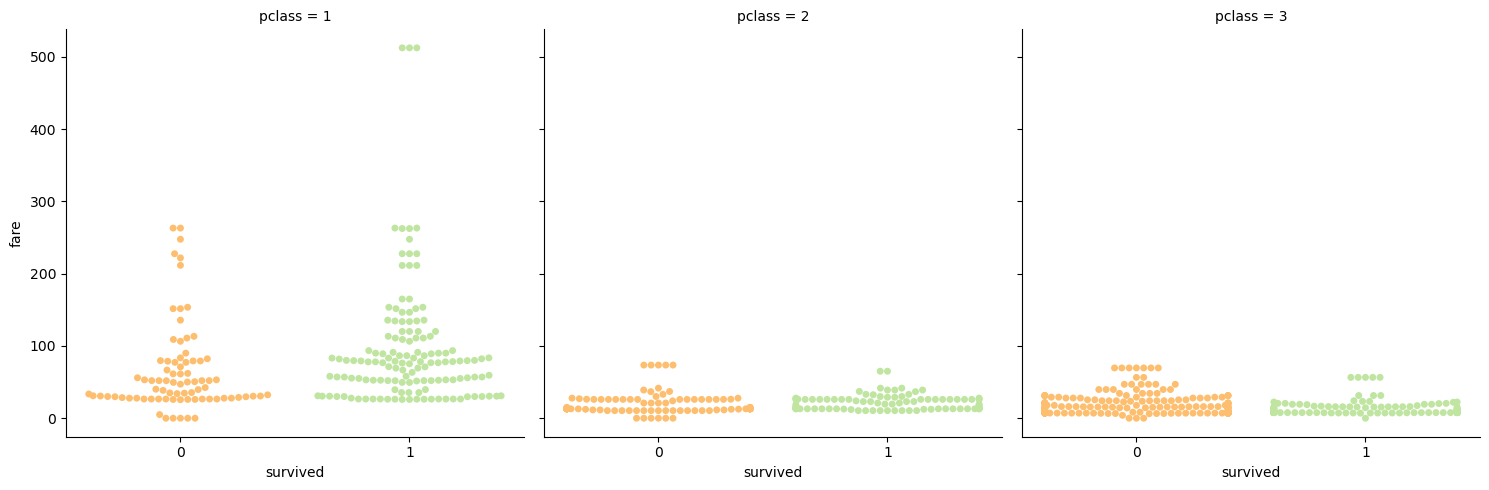

In [27]:
#Grafico de abeja segun la tarifa para los sobreviventes separados por clases.
# No se muestra una clara relacion entre los que sobreviven y los que no dependiendo de la tarifa
sns.catplot(x='survived', y = 'fare', col='pclass', kind='swarm', data = df, palette = 'Spectral', hue = 'survived', legend = False)

## Supervivencia por hermanos/esposos

sibsp
0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: count, dtype: int64


<Axes: xlabel='sibsp', ylabel='count'>

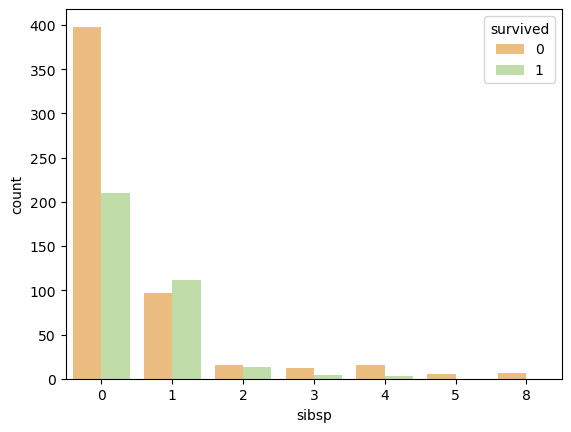

In [28]:
#Conteo de hermanos/esposos que tenia los pasajeros respecto a si sobrevivio o no.
print(df['sibsp'].value_counts())

sns.countplot(x = 'sibsp', hue = 'survived', data = df, palette= 'Spectral')

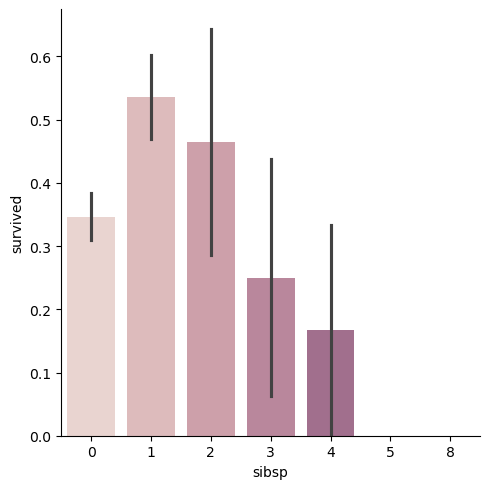

In [29]:
#Grafico de barras para mostrar la tasa de supervivencia respecto a los hermanos/eposos
# un menor numero de hermanos-eposos se aseguraba una mayor probabilidad de supervivencia, pero al no tener ninguno esta probabilidad baja drasticamente.
# Mientras mas hemanos se tenia, se incrementa la tasa de mortalidad, lo que indica que es inversamente proporcional a la supervivencia.
sns.catplot(x = 'sibsp', y='survived', data = df, kind = 'bar', hue = 'sibsp', legend = False)

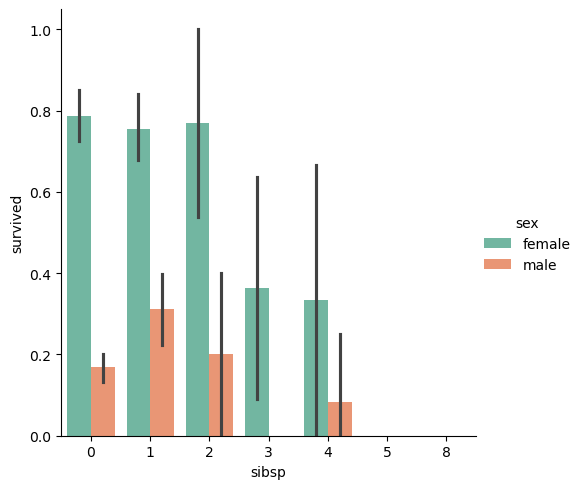

In [30]:
#Grafico de barras de tasa de mortalidad segun hermanos-eposos respecto al género.
# Esto confirma que al ser mujer, no importa la cantidad de hermanos que se tengan, la tasa de supervivencia siempre va a ser mayor al de los hombres.
# Al tener mas de 2 hermanos-esposos la tasa de supervivencia baja drasticamente en ambos generos, siendo el mas drastico el caso femenino.
# Todo esto puede indicar que en una sitacion de peligro/riesgo, siempre se priorizara el salvar a mujeres.
sns.catplot(x ='sibsp', y = 'survived',hue='sex', kind= 'bar', data = df, palette = "Set2")

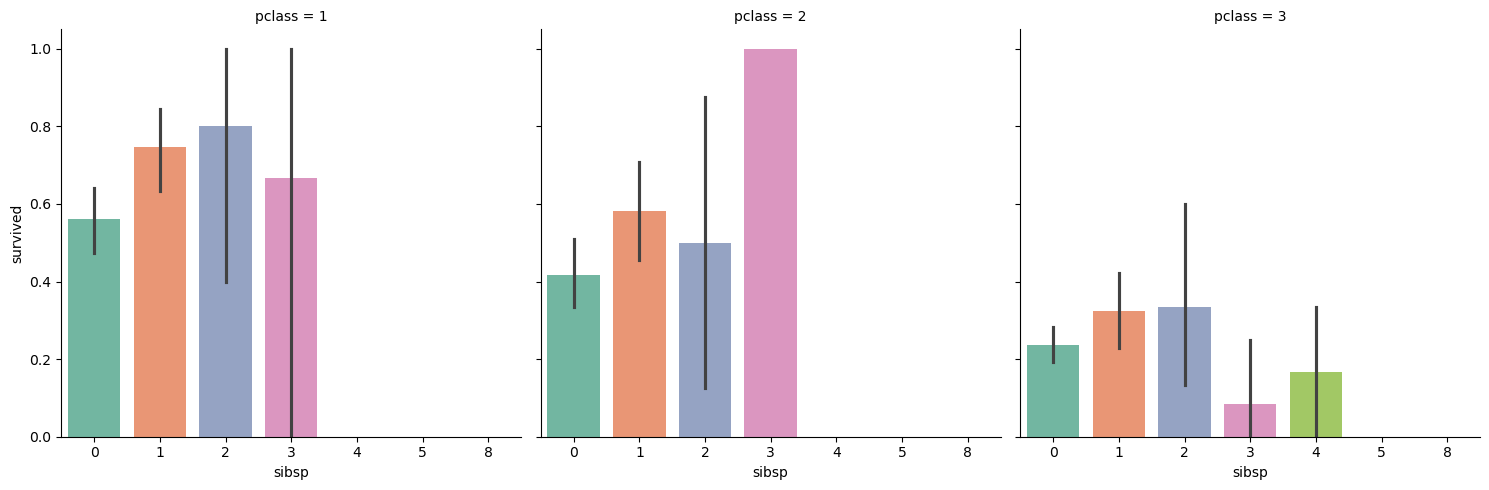

In [31]:
#Grafico que muestra la tasas de supervivencia segun la cantidad de hermanos-esposos, separados visualmente por clases.
# En las clases 1 y 2, ninguno tuvo mas de 4 hermanos-esposos y tuvieron una tasa de supervivencia muy alta, siendo la mayor los pasajeros de la seguna clase con 3 hermanos-esposos
# Mientras tanto en la clase3, tuvo la menor tasa de supervivencia en general.
# Por lo que mientras mas alta el nivel de clase de la familia de pasajeros, mas alta el probabilidad de que todos sobrevivan.

sns.catplot(x ='sibsp', y = 'survived',col='pclass', kind= 'bar', data = df, palette = "Set2", hue='sibsp', legend = False)

## Supervivencia segun Padres/Hijos

parch
0    678
1    118
2     80
5      5
3      5
4      4
6      1
Name: count, dtype: int64


<Axes: xlabel='parch', ylabel='count'>

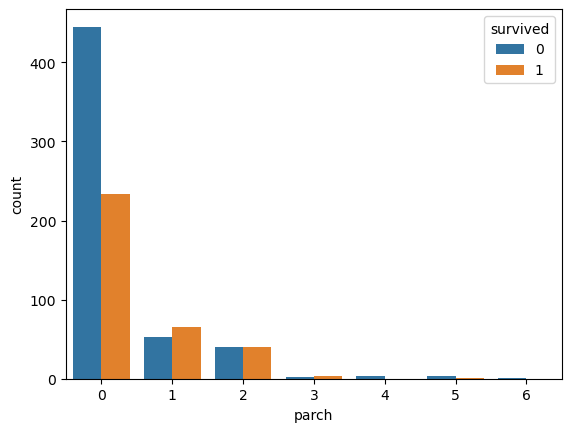

In [32]:
#Conteo y Grafico de padres-hijos por pasajero
print(df['parch'].value_counts())

sns.countplot(x = 'parch', hue ='survived', data = df)

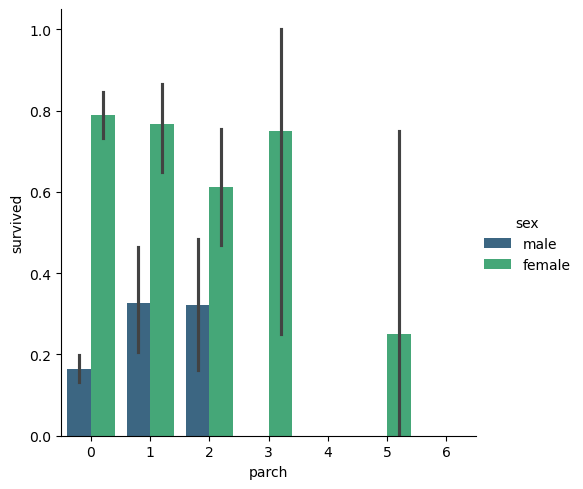

In [33]:
#Grafico de tasa de supervivencia segun los hijos-padres basados en su genero.
# Las mujeres tuvieron una tasas de supervivencia mas alta que las mujeres ent todos los casos, pero teniendo mas de 4 esta estadistica baja drasticamente.
# Notar tambien que al tener 1 o 2 padres-hijos, es la mayor probabilidad de supervivencia que tienen los hombres pero que aun sigue muy baja.
sns.catplot(x = 'parch', y = 'survived', hue = 'sex', kind= 'bar', data = df, palette='viridis')

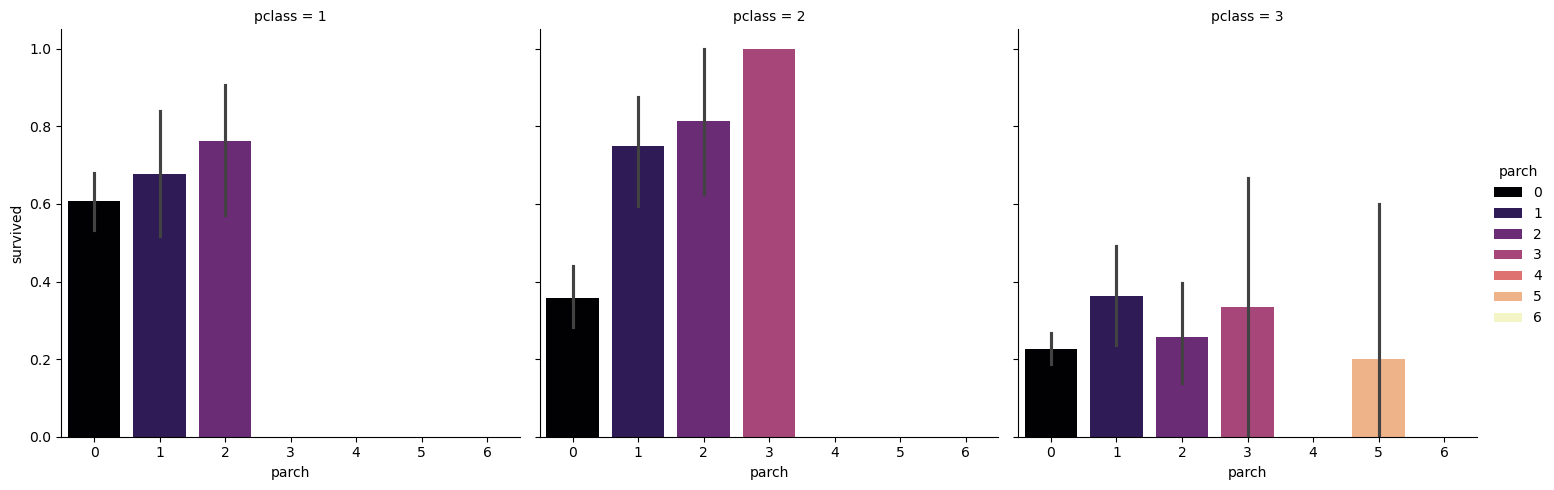

In [34]:
#Grafico de barras sobre la tasa de supervivencia de padres-hijos por cada clase.
# Esta grafica es bastante similar a la de hermanos-esposos debido a su directa correlacion.
# Nuevamente se indica que la seguna y primera clase fueron las que mas sobrevivieron siendo la mayor la familia de seguna clase.
# En tercera clase sobrevivio muy poca gente.
# La tercera clase fueron las familias con mayor numero de gente.
sns.catplot(x = 'parch', y = 'survived', col = 'pclass', hue = 'parch', kind= 'bar', data = df, palette='magma')

embarked
S    644
C    168
Q     77
Name: count, dtype: int64


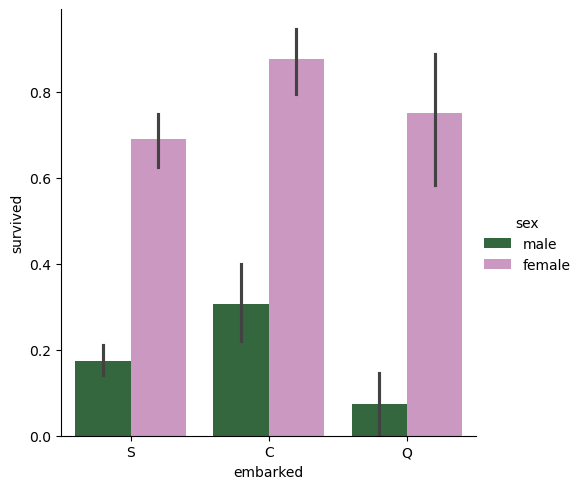

In [35]:
#Conteo y grafico de tasa de supervivencia segun el lugar de embarcacion detallando el tipo de genero.
print(df['embarked'].value_counts())

# Embarked Port of embarkation:
# C = Cherbourg Q = Queenstown S = Southhampton

# En general no hay mucha diferencia en la tasa de supervivencia dependiendo del de embarque.
# Se puede analizar que las mujeres tuvieron una tasa mucho mayor independiente del embarque.
# Una de las diferencias que se pueden observar en la tasa de supervivencia entre mujeres y hombres dependiendo del lugar de embarque, es que en Queenstown la disparidad fue mucho mas grande que 
# en las otras dos.
sns.catplot(x='embarked',y='survived',hue='sex',kind='bar', data = df, palette='cubehelix')

## Supervivencia segun hombre/mujer/niño y su clase 

who
man      537
woman    271
child     83
Name: count, dtype: int64


<Axes: xlabel='who', ylabel='count'>

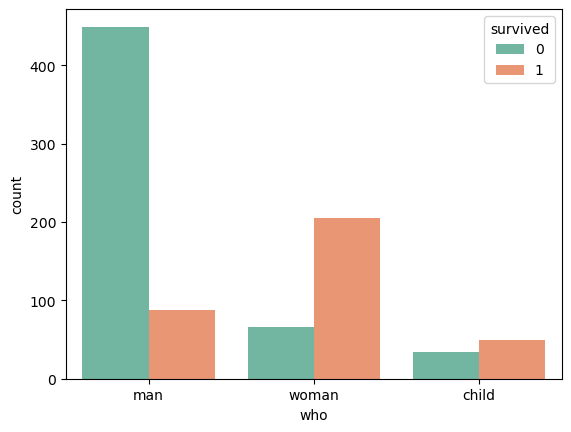

In [36]:
#Conteo y visualizacion de si la persona era hombre,mujer o niño y detallando si este sobrevivio o no.
print(df['who'].value_counts())

# Los hombres adulto fueron los que tuvieron una tasa de mortalidad significativamente mas alta en comparacion a los demas.
# Mujeres fueron las que sobrevivieron mas. Mientras las de los niños es casi la misma.
sns.countplot(x='who',hue='survived',data=df,palette='Set2')

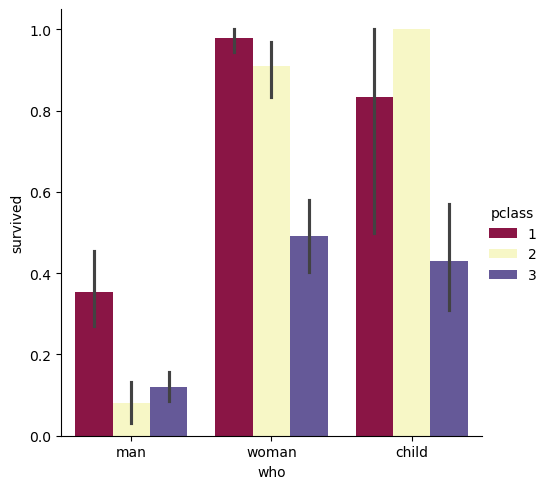

In [37]:
#Grafico de tasa de supervivencia  por persona dependiendo de su clase.
# Desafortunadamente se observa que la clase del pasajero influyó mas en las tasas de supervivencia que el genero de la persona.
# Incluso los niños se vieron afectados por el tipo de clase a la hora de sobrevivir en una tragedia.
sns.catplot(x='who', y='survived',hue='pclass',kind='bar',data=df, palette="Spectral")

# Conclusion

Tras analizar el Dataset de Titanic a traves de sus distintas variables, se puede concluir que en una tragedia como esta se va a seleccionar a las personas que sobrevivan o puedan sobrevivir dependiendo de su genero,clase y segun la edad que este tenga.

